# Evaluate StarCE SplitStar (EnableStarSplit)

Testing the impact of `EnableStarSplit` + `MaxStarSize` on accuracy, build time, and statistics size.

| Variant | EnableStarSplit | MaxStarSize | Description |
|------|-----------------|-------------|------|
| baseline | 0 | (not used) | Current default, full subset enumeration |
| max_fanout(3) | 1 | 3 | SplitStar default parameter |
| max_fanout(4) | 1 | 4 | Larger star block |
| max_fanout(5) | 1 | 5 | Larger star block |

Error metric: `relative_error = max(1, est) / max(1, true)`, plots use `log10(relative_error)`.

In [1]:
import os, sys, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import to_hex

sys.path.append(os.path.abspath('.'))
import plot_style

def get_project_root() -> Path:
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        if (parent / "Benchmark").exists() and (parent / "experiment").exists():
            return parent
    if "experiment" in str(cwd):
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()
CHECKPOINT_ROOT = PROJECT_ROOT / "experiment" / "checkpoint" / "StarCE" / "split_star"
FIGURE_DIR = PROJECT_ROOT / "experiment" / "checkpoint" / "figures"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

VARIANTS = [
    {'name': 'baseline', 'label': 'Baseline', 'enable': 0, 'max_star_size': 3},
    {'name': 'star3',    'label': 'max_fanout(3)', 'enable': 1, 'max_star_size': 3},
    {'name': 'star4',    'label': 'max_fanout(4)', 'enable': 1, 'max_star_size': 4},
    {'name': 'star5',    'label': 'max_fanout(5)', 'enable': 1, 'max_star_size': 5},
]
BENCHMARKS = ["STATS", "JOBM", "JOBLight", "JOBLightRanges"]

variant_names = [v['name'] for v in VARIANTS]
variant_labels = [v['label'] for v in VARIANTS]
n_variants = len(VARIANTS)

print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint: {CHECKPOINT_ROOT}")

Project root: /home/user/project/starce-final/StarCE
Checkpoint: /home/user/project/starce-final/StarCE/experiment/checkpoint/StarCE/split_star


---

# Experiment Section

Run StarCE, collect build time, statistics size, and subquery cardinality estimates, export to CSV.

In [2]:
# ============================================================
# Experiment Configuration
# ============================================================
from ExperimentRunner import StarCETestRunner, setup_starce_executable

RUN_STARCE = True
NUM_RUNS = 3  # Number of build time measurements (warmup not counted)

runner = StarCETestRunner(str(PROJECT_ROOT))
setup_starce_executable(PROJECT_ROOT, runner.running_space)

# Ensure dummy SQL exists
dummy_sql = runner.running_space / "dummy_query.sql"
if not dummy_sql.exists():
    dummy_sql.write_text("SELECT 1;\n")

print(f"RUN_STARCE={RUN_STARCE}, NUM_RUNS={NUM_RUNS}")

Successfully copied starce executable to: /home/user/project/starce-final/StarCE/experiment/running_space/starce
RUN_STARCE=True, NUM_RUNS=3


In [3]:
# Helper Functions
def resolve_real_path(benchmark: str) -> Path:
    mapping = {
        "STATS": PROJECT_ROOT / "Benchmark/workloads/STATS-CEB/subquery/result/real.txt",
        "JOBM": PROJECT_ROOT / "Benchmark/workloads/JOBM/subquery/result/real.txt",
        "JOBLight": PROJECT_ROOT / "Benchmark/workloads/JOBLight/subquery/result/real.txt",
        "JOBLightRanges": PROJECT_ROOT / "Benchmark/workloads/JOBLightRanges/subquery/result/real.txt",
    }
    return mapping[benchmark]

def get_benchmark_config(benchmark: str):
    if benchmark == "STATS":      return runner.get_stats_config()
    if benchmark == "JOBM":       return runner.get_jobm_config()
    if benchmark == "JOBLight":   return runner.get_joblight_config()
    if benchmark == "JOBLightRanges": return runner.get_joblight_ranges_config()
    raise ValueError(f"Unknown benchmark: {benchmark}")

def queries_file_path(benchmark: str) -> Path:
    return Path(get_benchmark_config(benchmark).SQL_PATH)

def stats_filename(benchmark: str, variant: dict) -> str:
    return f"statistics_{benchmark}_{variant['name']}.json"

def output_path(benchmark: str, variant: dict) -> Path:
    out_dir = CHECKPOINT_ROOT / benchmark
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"card_{benchmark}_{variant['name']}.txt"

def read_txt_file(file_path: Path) -> list[float]:
    values = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            s = line.strip()
            if s:
                values.append(float(s))
    return values

print("Helper functions defined.")

Helper functions defined.


In [4]:
# ============================================================
# Phase 1: Build Time + Statistics Size Measurement
# ============================================================
build_results = []
for benchmark in BENCHMARKS:
    for variant in VARIANTS:
        label = f"{benchmark}/{variant['name']}"
        stats_file = stats_filename(benchmark, variant)
        stats_abs = runner.running_space / stats_file
        if RUN_STARCE:
            print(f"\n=== Phase 1 [{label}]: Build time + size ===")
            config = get_benchmark_config(benchmark)
            config.EnableStarSplit = variant['enable']
            config.MaxStarSize = variant['max_star_size']
            config.RefreshStatistics = 1
            config.RecordingSubquery = 0
            config.SQL_PATH = "dummy_query.sql"
            config.STATS_PATH = stats_file

            # warmup
            if stats_abs.exists():
                stats_abs.unlink()
            runner.save_config(config)
            runner.run_starce(suppress_output=True)

            times = []
            for run_i in range(NUM_RUNS):
                if stats_abs.exists():
                    stats_abs.unlink()
                runner.save_config(config)
                success, elapsed = runner.run_starce(suppress_output=True)
                if success:
                    times.append(elapsed)
            if not times:
                raise RuntimeError(f"All runs failed for {label}")
            avg_time = sum(times) / len(times)

            size_path = runner.running_space / "statistics_size.json"
            with open(size_path, 'r') as f:
                size_report = json.load(f)
            size_bytes = size_report["data_only"]
            size_mb = size_bytes / (1024 * 1024)
            print(f"  Build: avg={avg_time:.3f}s  Size: {size_mb:.2f} MB")
        else:
            print(f"\n=== Phase 1 [{label}]: SKIP ===")
            avg_time = None
            size_bytes = None
            size_mb = None

        build_results.append({
            'benchmark': benchmark, 'variant': variant['name'],
            'variant_label': variant['label'],
            'enable_star_split': variant['enable'],
            'max_star_size': variant['max_star_size'],
            'build_time_sec': avg_time,
            'build_time_min': min(times) if (RUN_STARCE and times) else None,
            'build_time_max': max(times) if (RUN_STARCE and times) else None,
            'statistics_size_bytes': size_bytes,
            'statistics_size_mb': size_mb,
        })

df_build = pd.DataFrame(build_results)
print(f"\nPhase 1 done: {len(df_build)} rows")


=== Phase 1 [STATS/baseline]: Build time + size ===
[2026-07-26 19:45:41] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:45:41] starce ran successfully, elapsed: 0.12  seconds
[2026-07-26 19:45:41] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:45:41] starce ran successfully, elapsed: 0.12  seconds
[2026-07-26 19:45:41] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:45:41] starce ran successfully, elapsed: 0.12  seconds
[2026-07-26 19:45:41] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:45:41] starce ran successfully, elapsed: 0.12  seconds
  Build: avg=0.120s  Size: 0.12 MB

=== Phase 1 [STATS/star3]: Build time + size ===
[2026-07-26 19:45:41] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_

In [5]:
# ============================================================
# Phase 2: Subquery Cardinality Estimate Collection
# ============================================================
est_results = []
for benchmark in BENCHMARKS:
    real_path = resolve_real_path(benchmark)
    if not real_path.exists():
        raise FileNotFoundError(f"Real card file not found: {real_path}")
    queries_file = queries_file_path(benchmark)
    for variant in VARIANTS:
        label = f"{benchmark}/{variant['name']}"
        out = output_path(benchmark, variant)
        stats_file = stats_filename(benchmark, variant)
        if RUN_STARCE:
            print(f"\n=== Phase 2 [{label}]: Estimation ===")
            config = get_benchmark_config(benchmark)
            config.EnableStarSplit = variant['enable']
            config.MaxStarSize = variant['max_star_size']
            config.RefreshStatistics = 0
            config.STATS_PATH = stats_file
            config.RecordingSubquery = 1
            config.SUBQUERY_PATH = "null.sql"
            config.SUBQUERY_RESULT_PATH = str(out)
            explain_sql = runner.running_space / "explain.sql"
            runner._prepare_input_sql_with_explain(queries_file, explain_sql)
            config.SQL_PATH = "explain.sql"
            runner.save_config(config)
            success, elapsed = runner.run_starce(suppress_output=True)
            if not success:
                raise RuntimeError(f"Estimation failed: {label}")
            print(f"  Time: {elapsed:.3f}s  Output: {out}")
        else:
            print(f"\n=== Phase 2 [{label}]: SKIP ===")
        if not out.exists():
            raise FileNotFoundError(f"Missing: {out}")
        est_results.append({'benchmark': benchmark, 'variant': variant['name'],
            'variant_label': variant['label'], 'output_file': str(out),
            'num_queries': len(read_txt_file(out))})
print(f"\nPhase 2 done: {len(est_results)} outputs")


=== Phase 2 [STATS/baseline]: Estimation ===
[2026-07-26 19:49:39] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/explain.sql  and added EXPLAIN
[2026-07-26 19:49:39] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:49:39] starce ran successfully, elapsed: 0.20  seconds
  Time: 0.203s  Output: /home/user/project/starce-final/StarCE/experiment/checkpoint/StarCE/split_star/STATS/card_STATS_baseline.txt

=== Phase 2 [STATS/star3]: Estimation ===
[2026-07-26 19:49:39] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/explain.sql  and added EXPLAIN
[2026-07-26 19:49:39] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:49:39] starce ran successfully, elapsed: 0.20  seconds
  Time: 0.203s  Output: /home/user/project/starce-final/StarCE/experiment/checkpoint/StarCE/split_star/STATS/card_STAT

In [6]:
# ============================================================
# Error Calculation + CSV Export
# ============================================================
all_error_data = {}
csv_rows = []
for benchmark in BENCHMARKS:
    true_values = read_txt_file(resolve_real_path(benchmark))
    per_bm = {}
    for variant in VARIANTS:
        est_values = read_txt_file(output_path(benchmark, variant))
        rel_errors = []
        for idx, (t, e) in enumerate(zip(true_values, est_values)):
            re = max(1.0, e) / max(1.0, t)
            rel_errors.append(re)
            csv_rows.append({'benchmark': benchmark, 'variant': variant['name'],
                'variant_label': variant['label'], 'enable_star_split': variant['enable'],
                'max_star_size': variant['max_star_size'], 'query_idx': idx,
                'true_card': t, 'est_card': e, 'rel_error': re,
                'log10_rel_error': np.log10(max(re, 1e-10))})
        per_bm[variant['name']] = rel_errors
        log_vals = np.log10(np.maximum(np.array(rel_errors), 1e-10))
        print(f"{benchmark} {variant['name']}: n={len(rel_errors)}, "
              f"log10(err) min={np.min(log_vals):.6g}, max={np.max(log_vals):.6g}")
    all_error_data[benchmark] = per_bm

df_csv = pd.DataFrame(csv_rows)
csv_path = CHECKPOINT_ROOT / "splitstar_error_data.csv"
df_csv.to_csv(csv_path, index=False)
print(f"\nError CSV: {csv_path} ({len(df_csv)} rows)")

build_csv = CHECKPOINT_ROOT / "splitstar_build_results.csv"
df_build.to_csv(build_csv, index=False)
print(f"Build CSV: {build_csv}")

# Summary statistics
print(f"\n{'Benchmark':<16} {'Variant':<14} {'P50':>8} {'P90':>8} {'P95':>8} {'P99':>8} {'Max':>8} {'log10_mean':>10} {'log10_std':>10}")
print("-" * 100)
summary_rows = []
for benchmark in BENCHMARKS:
    for variant in VARIANTS:
        vn = variant['name']
        arr = np.array(all_error_data[benchmark][vn])
        log_arr = np.log10(np.maximum(arr, 1e-10))
        p50, p90, p95, p99 = np.quantile(arr, [0.50, 0.90, 0.95, 0.99])
        mx, lm, ls = np.max(arr), np.mean(log_arr), np.std(log_arr)
        print(f"{benchmark:<16} {vn:<14} {p50:8.4f} {p90:8.4f} {p95:8.4f} {p99:8.4f} {mx:8.4f} {lm:10.4f} {ls:10.4f}")
        summary_rows.append({'benchmark': benchmark, 'variant': vn,
            'P50': p50, 'P90': p90, 'P95': p95, 'P99': p99, 'Max': mx,
            'log10_mean': lm, 'log10_std': ls})
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(CHECKPOINT_ROOT / "splitstar_summary.csv", index=False)
print(f"Summary CSV exported.")

STATS baseline: n=2471, log10(err) min=-1.53186, max=8.64395
STATS star3: n=2471, log10(err) min=-1.53186, max=8.75099
STATS star4: n=2471, log10(err) min=-1.53186, max=8.75099
STATS star5: n=2471, log10(err) min=-1.53186, max=8.64395
JOBM baseline: n=6424, log10(err) min=-3.74961, max=4.51145
JOBM star3: n=6424, log10(err) min=-3.74961, max=4.51145
JOBM star4: n=6424, log10(err) min=-3.74961, max=4.51145
JOBM star5: n=6424, log10(err) min=-3.74961, max=4.51145
JOBLight baseline: n=451, log10(err) min=-1.79239, max=1.6101
JOBLight star3: n=451, log10(err) min=-1.79239, max=1.8761
JOBLight star4: n=451, log10(err) min=-1.79239, max=1.6101
JOBLight star5: n=451, log10(err) min=-1.79239, max=1.6101
JOBLightRanges baseline: n=8292, log10(err) min=-2.72951, max=5.42974
JOBLightRanges star3: n=8292, log10(err) min=-2.57948, max=5.42974
JOBLightRanges star4: n=8292, log10(err) min=-2.57948, max=5.42974
JOBLightRanges star5: n=8292, log10(err) min=-2.72951, max=5.42974

Error CSV: /home/user/p

---

# Plotting Section

Read data from checkpoint CSV and plot. **Can be run directly from here without re-running experiments.**

Data sources:
- `splitstar_error_data.csv` — per-query errors
- `splitstar_build_results.csv` — build time & statistics size

In [7]:
# ============================================================
# Load data from CSV + plot color scheme
# ============================================================

# Variant info (must match experiment section)
VARIANTS = [
    {'name': 'baseline', 'label': 'Baseline', 'enable': 0, 'max_star_size': 3},
    {'name': 'star3',    'label': 'max_fanout(3)', 'enable': 1, 'max_star_size': 3},
    {'name': 'star4',    'label': 'max_fanout(4)', 'enable': 1, 'max_star_size': 4},
    {'name': 'star5',    'label': 'max_fanout(5)', 'enable': 1, 'max_star_size': 5},
]
variant_names = [v['name'] for v in VARIANTS]
variant_labels = [v['label'] for v in VARIANTS]
n_variants = len(VARIANTS)
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c']  # red=baseline, blue/orange/green

# Load error data
error_csv = CHECKPOINT_ROOT / "splitstar_error_data.csv"
if not error_csv.exists():
    raise FileNotFoundError(f"Error data not found: {error_csv}. Please run the experiment section first.")
df_err = pd.read_csv(error_csv)
print(f"Loaded error data: {len(df_err)} rows")

all_error_data = {}
for benchmark in BENCHMARKS:
    per_bm = {}
    for v in VARIANTS:
        mask = (df_err['benchmark'] == benchmark) & (df_err['variant'] == v['name'])
        vals = df_err[mask]['rel_error'].tolist()
        if vals:
            per_bm[v['name']] = vals
    if per_bm:
        all_error_data[benchmark] = per_bm
print(f"Reconstructed all_error_data: {list(all_error_data.keys())}")

# Load build results
build_csv = CHECKPOINT_ROOT / "splitstar_build_results.csv"
if build_csv.exists():
    df_build = pd.read_csv(build_csv)
    print(f"Loaded build results: {len(df_build)} rows")
else:
    print("Warning: build results CSV not found")
    df_build = None

Loaded error data: 70552 rows
Reconstructed all_error_data: ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']
Loaded build results: 16 rows


In [8]:
# Summary statistics
print(f"{'Benchmark':<16} {'Variant':<14} {'P50':>8} {'P90':>8} {'P95':>8} {'P99':>8} {'Max':>8} {'log10_mean':>10} {'log10_std':>10}")
print("-" * 100)
for benchmark in BENCHMARKS:
    if benchmark not in all_error_data:
        continue
    for v in VARIANTS:
        vn = v['name']
        if vn not in all_error_data[benchmark]:
            continue
        arr = np.array(all_error_data[benchmark][vn])
        log_arr = np.log10(np.maximum(arr, 1e-10))
        p50, p90, p95, p99 = np.quantile(arr, [0.50, 0.90, 0.95, 0.99])
        mx, lm, ls = np.max(arr), np.mean(log_arr), np.std(log_arr)
        print(f"{benchmark:<16} {vn:<14} {p50:8.4f} {p90:8.4f} {p95:8.4f} {p99:8.4f} {mx:8.4f} {lm:10.4f} {ls:10.4f}")

Benchmark        Variant             P50      P90      P95      P99      Max log10_mean  log10_std
----------------------------------------------------------------------------------------------------
STATS            baseline         1.2554  27.8547 127.6319 10567.5121 440503851.9934     0.3691     0.9480
STATS            star3            1.4399  35.8549 167.0784 21134.1508 563627208.2670     0.4511     0.9867
STATS            star4            1.2715  28.7149 128.7575 12308.8590 563627208.2670     0.3787     0.9564
STATS            star5            1.2554  27.8547 127.6319 10567.5121 440503851.9934     0.3691     0.9480
JOBM             baseline         1.1088  25.6621  67.8931 380.9379 32467.5000     0.0713     1.0684
JOBM             star3            1.4729 191.6020 635.8314 4065.8733 32467.5000     0.3410     1.3225
JOBM             star4            1.1871  80.1691 496.8766 6997.7594 32467.5000     0.2162     1.2701
JOBM             star5            1.1123  32.6851 104.6051 2026.967

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/splitstar_build_time.pdf


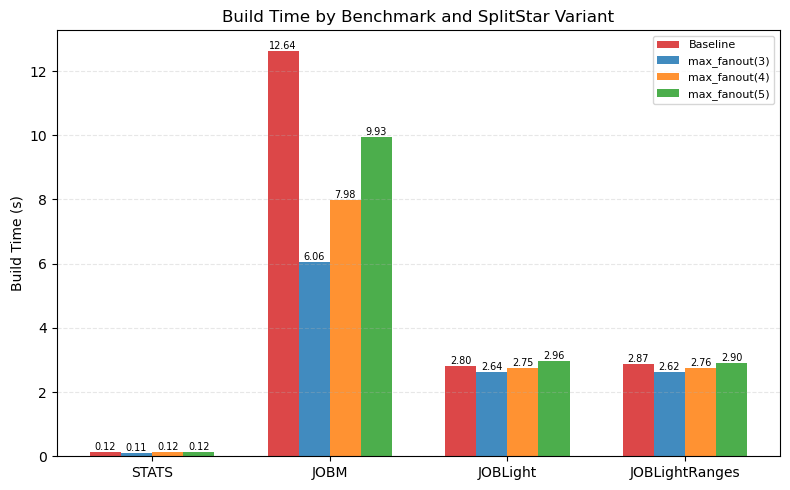

In [9]:
# Build time bar chart
if df_build is not None:
    fig, ax = plt.subplots(figsize=(max(8, len(BENCHMARKS) * 1.5), 5))
    x = np.arange(len(BENCHMARKS))
    width = 0.7 / n_variants
    for i, (vn, vl, color) in enumerate(zip(variant_names, variant_labels, colors)):
        values = []
        for bm in BENCHMARKS:
            row = df_build[(df_build['benchmark'] == bm) & (df_build['variant'] == vn)]
            if row.empty:
                values.append(0)
            else:
                val = row.iloc[0]['build_time_sec']
                values.append(val if val is not None and not (isinstance(val, float) and np.isnan(val)) else 0)
        offset = (i - (n_variants - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=vl, color=color, alpha=0.85)
        for pos, val in zip(x + offset, values):
            if val > 0:
                ax.text(pos, val, f'{val:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_ylabel('Build Time (s)')
    ax.set_title('Build Time by Benchmark and SplitStar Variant')
    ax.set_xticks(x)
    ax.set_xticklabels(BENCHMARKS)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    f = FIGURE_DIR / "splitstar_build_time.pdf"
    plt.savefig(f)
    print(f"Saved: {f}")
    plt.show()
else:
    print("Build results not available")

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/splitstar_statistics_size.pdf


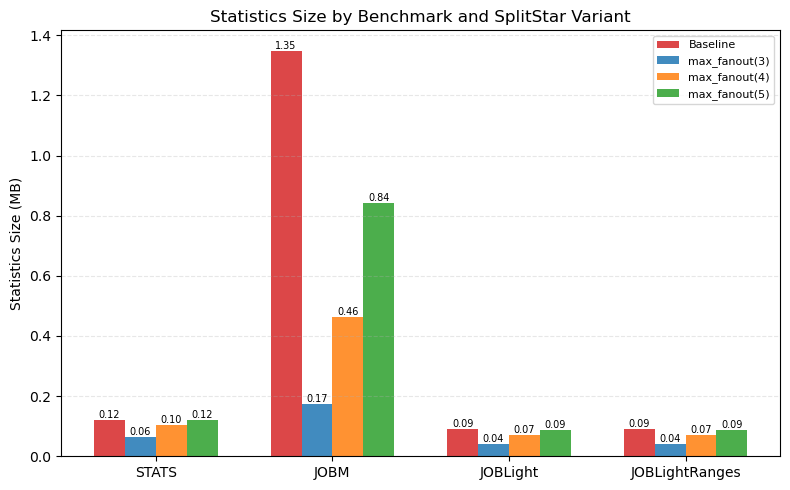

In [10]:
# Statistics size bar chart
if df_build is not None:
    fig, ax = plt.subplots(figsize=(max(8, len(BENCHMARKS) * 1.5), 5))
    for i, (vn, vl, color) in enumerate(zip(variant_names, variant_labels, colors)):
        values = []
        for bm in BENCHMARKS:
            row = df_build[(df_build['benchmark'] == bm) & (df_build['variant'] == vn)]
            if row.empty:
                values.append(0)
            else:
                val = row.iloc[0]['statistics_size_mb']
                values.append(val if val is not None and not (isinstance(val, float) and np.isnan(val)) else 0)
        offset = (i - (n_variants - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=vl, color=color, alpha=0.85)
        for pos, val in zip(x + offset, values):
            if val > 0:
                ax.text(pos, val, f'{val:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_ylabel('Statistics Size (MB)')
    ax.set_title('Statistics Size by Benchmark and SplitStar Variant')
    ax.set_xticks(x)
    ax.set_xticklabels(BENCHMARKS)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    f = FIGURE_DIR / "splitstar_statistics_size.pdf"
    plt.savefig(f)
    print(f"Saved: {f}")
    plt.show()
else:
    print("Build results not available")

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/splitstar_accuracy_boxplot.pdf


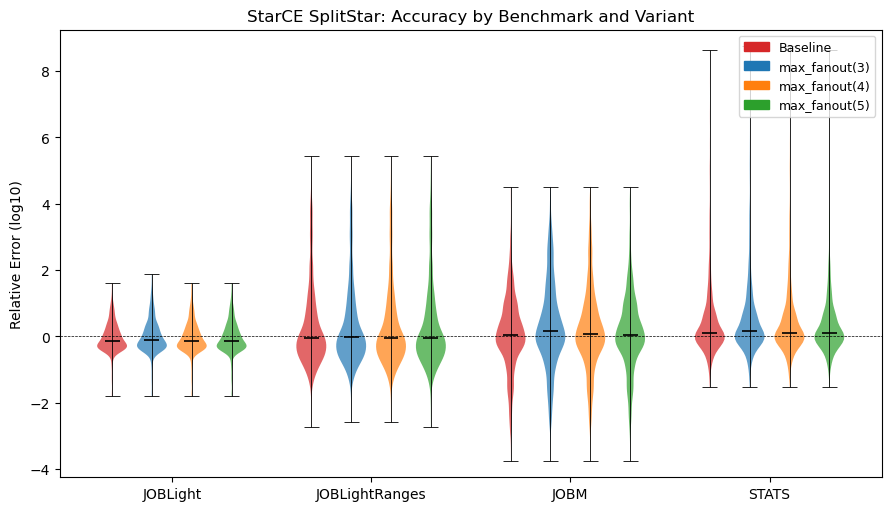

In [11]:
# Accuracy violin plot (grouped by benchmark)
fig, ax = plt.subplots(layout="constrained", figsize=(max(7, len(BENCHMARKS) * 2.2), 5))
positions, violin_data, violin_colors = [], [], []
benchmark_centers, benchmark_labels = [], []
group_width, group_gap = 0.9, 0.6

for idx, bm in enumerate(sorted(all_error_data.keys()), start=1):
    base_pos = (idx - 1) * (group_width + group_gap) + 1
    offsets = np.linspace(-group_width / 2, group_width / 2, n_variants)
    for offset, vn, color in zip(offsets, variant_names, colors):
        if vn not in all_error_data.get(bm, {}):
            continue
        pos = base_pos + float(offset)
        log_errs = np.log10(np.maximum(np.array(all_error_data[bm][vn]), 1e-10))
        positions.append(pos)
        violin_data.append(log_errs)
        violin_colors.append(color)
    benchmark_centers.append(base_pos)
    benchmark_labels.append(bm)

plot_style.draw_violins(ax, violin_data, positions, violin_colors,
                        widths=group_width / max(n_variants, 1))
all_log = np.concatenate(violin_data)
ax.set_ylim(np.min(all_log) - 0.5, np.max(all_log) + 0.5)
ax.set_ylabel("Relative Error (log10)")
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax.set_xticks(benchmark_centers)
ax.set_xticklabels(benchmark_labels)
ax.set_title("StarCE SplitStar: Accuracy by Benchmark and Variant")
ax.legend(handles=[mpl.patches.Patch(color=c, label=l) for c, l in zip(colors, variant_labels)],
          fontsize=9, loc="best")
f = FIGURE_DIR / "splitstar_accuracy_boxplot.pdf"
plt.savefig(f)
print(f"Saved: {f}")
plt.show()

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/splitstar_build_time_stats_jobm.pdf


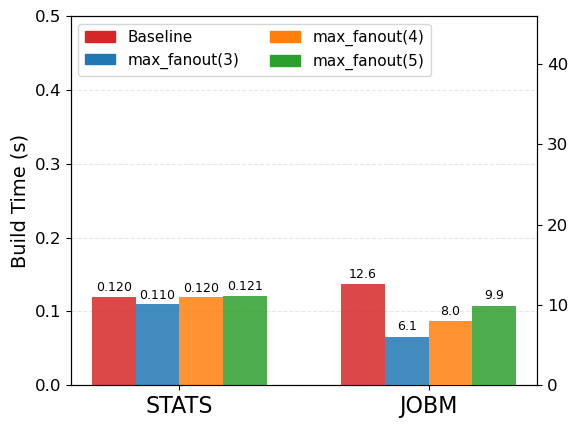

In [12]:
# Modified build time: STATS + JOBM only, dual y-axis
if df_build is not None:
    mpl.rcParams.update({'font.size': 14})
    selected = ["STATS", "JOBM"]
    data = {}
    for bm in selected:
        data[bm] = []
        for vn in variant_names:
            row = df_build[(df_build['benchmark'] == bm) & (df_build['variant'] == vn)]
            val = row.iloc[0]['build_time_sec'] if not row.empty else 0
            data[bm].append(val if val is not None and not (isinstance(val, float) and np.isnan(val)) else 0)

    fig, ax_left = plt.subplots(figsize=(6, 4.5))
    ax_right = ax_left.twinx()
    x = np.arange(len(selected))
    width = 0.7 / n_variants
    for i, (vn, vl, color) in enumerate(zip(variant_names, variant_labels, colors)):
        offset = (i - (n_variants - 1) / 2) * width
        ax_left.bar(x[0] + offset, data['STATS'][i], width, color=color, alpha=0.85, zorder=3)
        ax_left.text(x[0] + offset, data['STATS'][i] + 0.003, f'{data["STATS"][i]:.3f}',
                     ha='center', va='bottom', fontsize=9)
        ax_right.bar(x[1] + offset, data['JOBM'][i], width, color=color, alpha=0.85, zorder=3)
        ax_right.text(x[1] + offset, data['JOBM'][i] + 0.4, f'{data["JOBM"][i]:.1f}',
                      ha='center', va='bottom', fontsize=9)
    ax_left.set_ylim(0, 0.5)
    ax_right.set_ylim(0, 46)
    ax_left.set_ylabel('Build Time (s)', fontsize=14)
    ax_left.tick_params(axis='y', labelsize=12)
    ax_right.tick_params(axis='y', labelsize=12)
    ax_left.set_xticks(x)
    ax_left.set_xticklabels(selected, fontsize=16)
    ax_left.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax_left.legend(handles=[mpl.patches.Patch(color=c, label=l) for c, l in zip(colors, variant_labels)],
                   fontsize=11, loc='upper left', ncol=2)
    plt.tight_layout()
    f = FIGURE_DIR / "splitstar_build_time_stats_jobm.pdf"
    plt.savefig(f, bbox_inches='tight')
    print(f"Saved: {f}")
    plt.show()
    mpl.rcParams.update({'font.size': 10})
else:
    print("Build results not available")

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/splitstar_accuracy_boxplot_stats_jobm.pdf


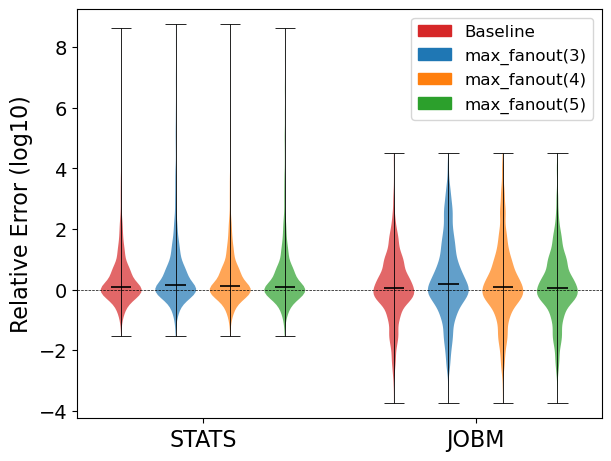

In [13]:
# Modified accuracy violin plot: STATS + JOBM only
mpl.rcParams.update({'font.size': 14})
selected = ["STATS", "JOBM"]
fig, ax = plt.subplots(layout="constrained", figsize=(6, 4.5))
positions, violin_data, violin_colors = [], [], []
benchmark_centers, benchmark_labels = [], []
group_width, group_gap = 0.9, 0.6

for idx, bm in enumerate(selected, start=1):
    if bm not in all_error_data:
        continue
    base_pos = (idx - 1) * (group_width + group_gap) + 1
    offsets = np.linspace(-group_width / 2, group_width / 2, n_variants)
    for offset, vn, color in zip(offsets, variant_names, colors):
        if vn not in all_error_data[bm]:
            continue
        pos = base_pos + float(offset)
        log_errs = np.log10(np.maximum(np.array(all_error_data[bm][vn]), 1e-10))
        positions.append(pos)
        violin_data.append(log_errs)
        violin_colors.append(color)
    benchmark_centers.append(base_pos)
    benchmark_labels.append(bm)

plot_style.draw_violins(ax, violin_data, positions, violin_colors,
                        widths=group_width / max(n_variants, 1))
all_log = np.concatenate(violin_data)
ax.set_ylim(np.min(all_log) - 0.5, np.max(all_log) + 0.5)
ax.set_ylabel("Relative Error (log10)", fontsize=16)
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax.set_xticks(benchmark_centers)
ax.set_xticklabels(benchmark_labels, fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.legend(handles=[mpl.patches.Patch(color=c, label=l) for c, l in zip(colors, variant_labels)],
          fontsize=12, loc="best")
f = FIGURE_DIR / "splitstar_accuracy_boxplot_stats_jobm.pdf"
plt.savefig(f, bbox_inches='tight')
print(f"Saved: {f}")
plt.show()
mpl.rcParams.update({'font.size': 10})